In [3]:
import random

import matplotlib.pyplot as plt
import torch
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ]),
    'test': transforms.Compose([
        transforms.ToTensor(),
    ]),
}

transform = transforms.Compose([transforms.ToTensor(),])

train_data = datasets.FashionMNIST(root="../data", train=True, download=True, transform=data_transforms["train"])
test_data = datasets.FashionMNIST(root="../data", train=False, download=True, transform=data_transforms["test"])

print(f"Train samples: {len(train_data)}, Test samples: {len(test_data)}")

Train samples: 60000, Test samples: 10000


In [5]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True) 
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

Batch shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])


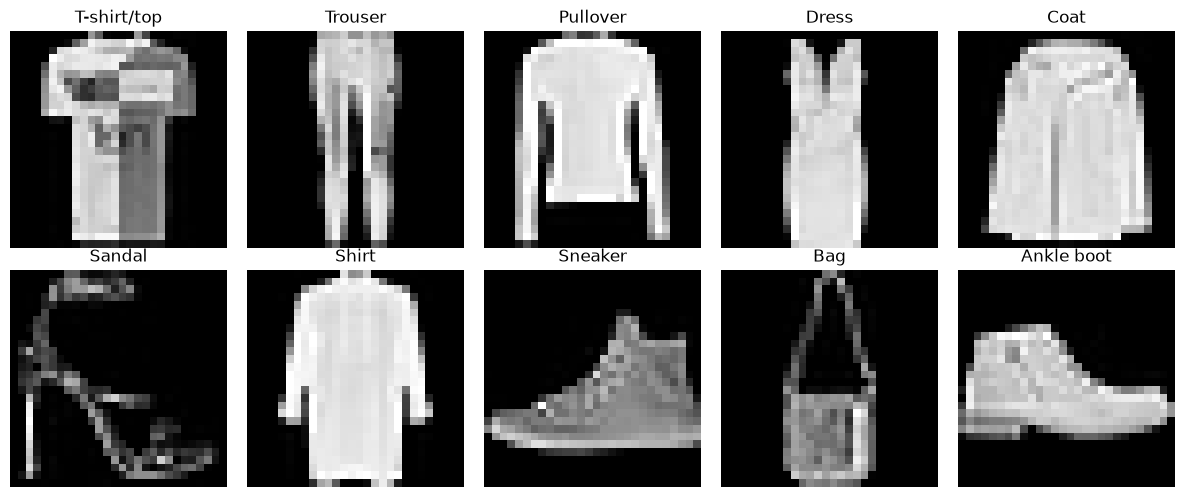

In [6]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

found = {}

for images, labels in train_loader:
    for img, label in zip(images, labels):
        label = label.item()
        if label not in found:
            found[label] = img
    if len(found) == 10:
        break

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for class_id in range(10):
    ax = axes[class_id // 5, class_id % 5]
    ax.imshow(found[class_id].squeeze(), cmap='gray')
    ax.set_title(class_names[class_id])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)                
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
num_epochs = 7
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 1/7, Loss: 0.5297
Epoch 2/7, Loss: 0.3416
Epoch 3/7, Loss: 0.2974
Epoch 4/7, Loss: 0.2741
Epoch 5/7, Loss: 0.2519
Epoch 6/7, Loss: 0.2348
Epoch 7/7, Loss: 0.2195


In [10]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

train_accuracy = 100 * correct / total
print(f"Test train_accuracy: {train_accuracy:.2f}%")

Test train_accuracy: 92.06%


In [11]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"Test test_accuracy: {test_accuracy:.2f}%")

Test test_accuracy: 90.03%


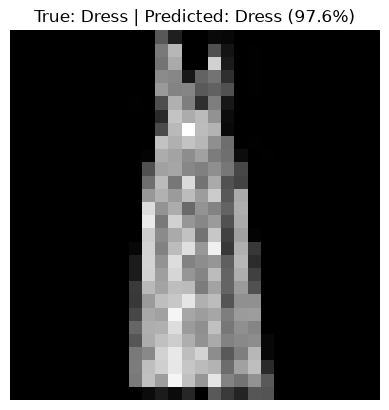

In [12]:
model.eval()
idx = random.randint(0, len(test_data) - 1)
image, true_label = test_data[idx]

with torch.no_grad():
    output = model(image.unsqueeze(0).to(device))
    probs = torch.softmax(output, dim=1)
    confidence, predicted = torch.max(probs, 1)

plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"True: {class_names[true_label]} | Predicted: {class_names[predicted.item()]} ({confidence.item()*100:.1f}%)")
plt.axis('off')
plt.show()

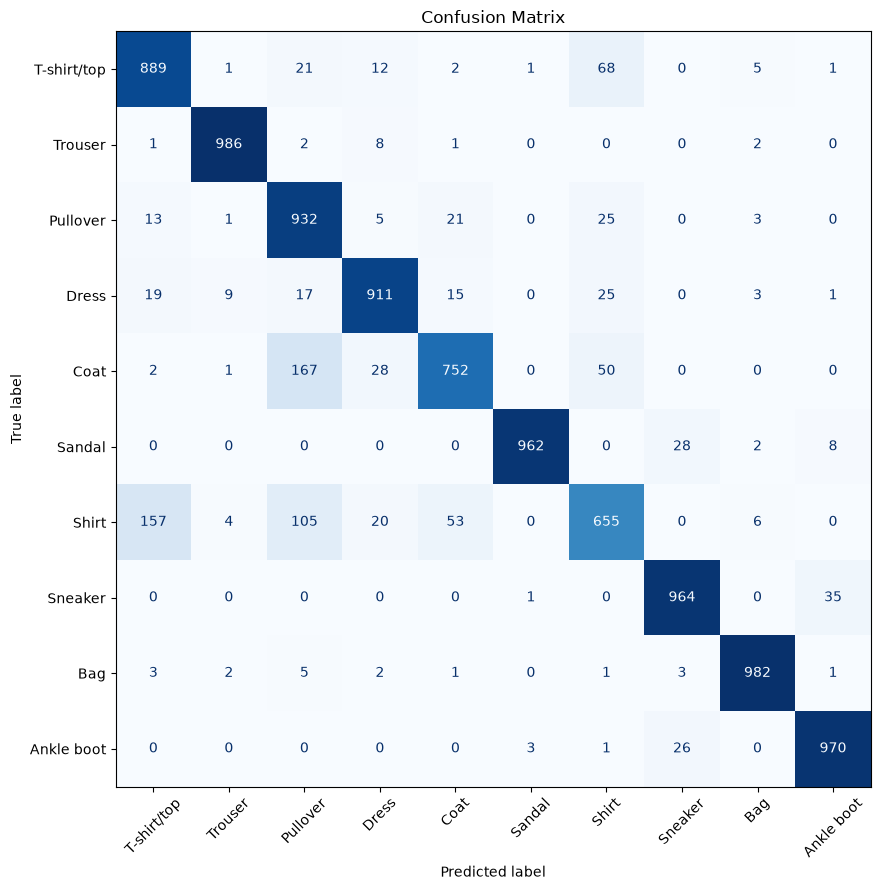

In [13]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(9, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()